# Ejercicio 2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import scipy as sp
import numdifftools as nd

In [2]:
df = pd.read_csv("datos_Blanton.csv") #cargamos y visualisamos los datos
df.head()

,MAG,PHI,error_inf,error_sup
0,-23.183,0.000003,0.000001,0.000006
1,-23.020,0.000005,0.000003,0.000011
2,-22.870,0.000017,0.000013,0.000026
3,-22.698,0.000035,0.000025,0.000044
4,-22.565,0.000082,0.000058,0.000105


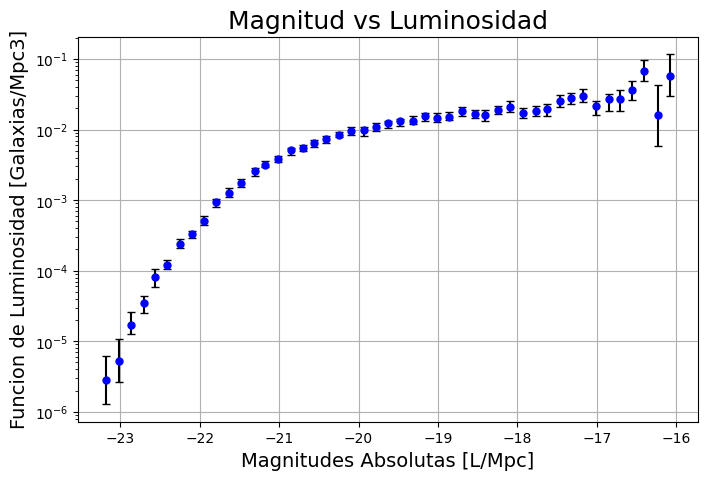

In [3]:
plt.figure(figsize=(8,5))
error_s =  df['error_sup'] - df['PHI']
error_i =  -df['error_inf'] + df['PHI']
plt.errorbar(df['MAG'], df['PHI'],  yerr = [error_i,error_s], fmt='ob',ms = 5,  capsize=3,  ecolor="k")
plt.xlabel('Magnitudes Absolutas [L/Mpc]',fontsize = 14) 
plt.ylabel('Funcion de Luminosidad [Galaxias/Mpc3]',fontsize = 14)
plt.yscale('log')
plt.grid()
plt.title('Magnitud vs Luminosidad',fontsize = 18 )
plt.show()

# Ejercicio 3

In [4]:
def schechter(M,phi0,a0,M0): # defino la funcion schecheter
    lista = []
    for i in range(len(M)):
        p = 10**((-0.4*(M[i] - M0))*(a0 + 1))
        r = np.exp(-10**(-0.4*(M[i] -M0 )))
        y =y=0.4 * np.log(10) * phi0 * p * r
        lista.append(y)
    return(lista)

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_59333/1719244748.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('$ M_r $  $[L/Mpc]$',fontsize = 14); plt.ylabel('$\phi(M_r)$  $[Galaxias/Mpc^3]$',fontsize = 14)


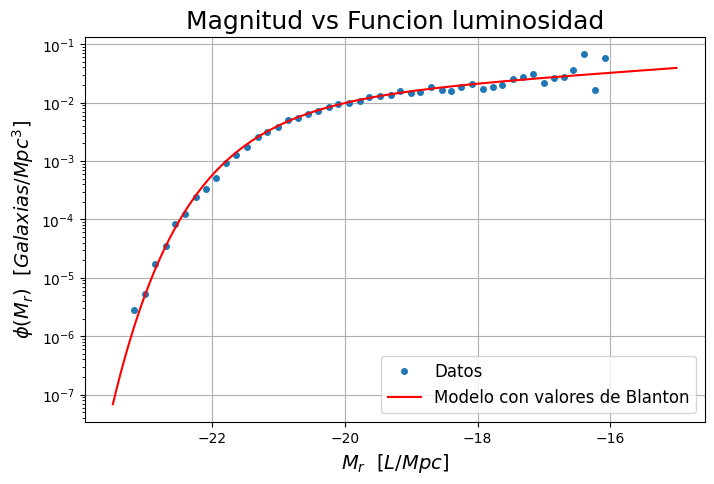

In [5]:
plt.figure(figsize=(8,5))
plt.plot(df['MAG'],df['PHI'],'o',label = 'Datos',ms = 4)
sx = np.linspace(-23.5, -15, 150)
sy = schechter(sx,0.0146,-1.20,-20.83) # estos valores son los obtenidos de Blanton et al. (2001).
plt.plot(sx,sy, color='red', label='Modelo con valores de Blanton')
plt.xlabel('$ M_r $  $[L/Mpc]$',fontsize = 14); plt.ylabel('$\phi(M_r)$  $[Galaxias/Mpc^3]$',fontsize = 14)
plt.yscale('log')
plt.grid()
plt.title('Magnitud vs Funcion luminosidad',fontsize = 18 )
plt.legend(loc = 'lower right',fontsize = 12)
plt.show()

Antes, definimos los errores de los datos, ya que vamos a suponer que los mismos soy gaussianos, donde los datos estan centrados en la gaussiana. Hacemos esta suposición de los errores ya que este modo el calculo de el likelihood se tranforma en una expresión mas sencilla.

In [6]:
error_s =  df['error_sup'] - df['PHI']
error_i =  -df['error_inf'] + df['PHI']
sigma = np.abs((error_s + error_i)/2)

In [7]:
def likelihood(M,phi,phi0,a0,M0,sigma):
    phi_model = schechter(M,phi0,a0,M0) # valor de phi calculado por el modelo 
    c = 1/(np.sqrt(2*np.pi)*sigma)
    w = (phi - phi_model)**2/((np.sqrt(2)*sigma))**2
    p = np.sum(w)                                        
    return(p)

In [8]:
def priors(phi0,a0,m0,philim,Alim,Mlim):
    if (philim[0]<= phi0) & (phi0 <= philim[1]) & (a0 >= Alim[0]) & (a0 <= Alim[1]) & (Mlim[0]<= m0) & (Mlim[1]>= m0):
        return 1 
    else:
        return 0

In [9]:
def posteriori (m,f,phi0,a0,m0,sigma,philim,Alim,Mlim): # esto es el log de la posteriori
    post = likelihood(m,f,phi0,a0,m0,sigma) + np.log(priors(phi0,a0,m0,philim,Alim,Mlim))
    return (post)

Luego, para definir el espacio de parametros vamos a ver como estos afectan al modelo y lo vamos a realizar de manera grafica.



In [10]:
fi0 = np.linspace(0.001,0.040,5) #
A0 = np.linspace(-3,0.,5)
m0 = np.linspace(-23,-19,5)
p = []
o = []
q = []
for i in range(5):        
    g = schechter(sx,fi0[i], -1.20, -20.83) # tengo q cambiar el likelihood por la schechter
    l = schechter(sx,0.0146, A0[i], -20.83)
    m = schechter(sx,0.0146, -1.20, m0[i])
    p.append(g)
    o.append(l)
    q.append(m)

<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:19: SyntaxWarning: invalid escape sequence '\p'
<>:29: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_59333/2760967791.py:8: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(sx,p[i], label=f"Modelo $ \phi_0$={fi0[i]}")
/tmp/ipykernel_59333/2760967791.py:9: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('$ M_r $  $[L/Mpc]$',fontsize = 14); plt.ylabel('$\phi(M_r)$  $[Galaxias/Mpc^3]$',fontsize = 14)
/tmp/ipykernel_59333/2760967791.py:12: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Magnitud vs Funcion luminosidad variando $\phi_0$',fontsize = 18 )
/

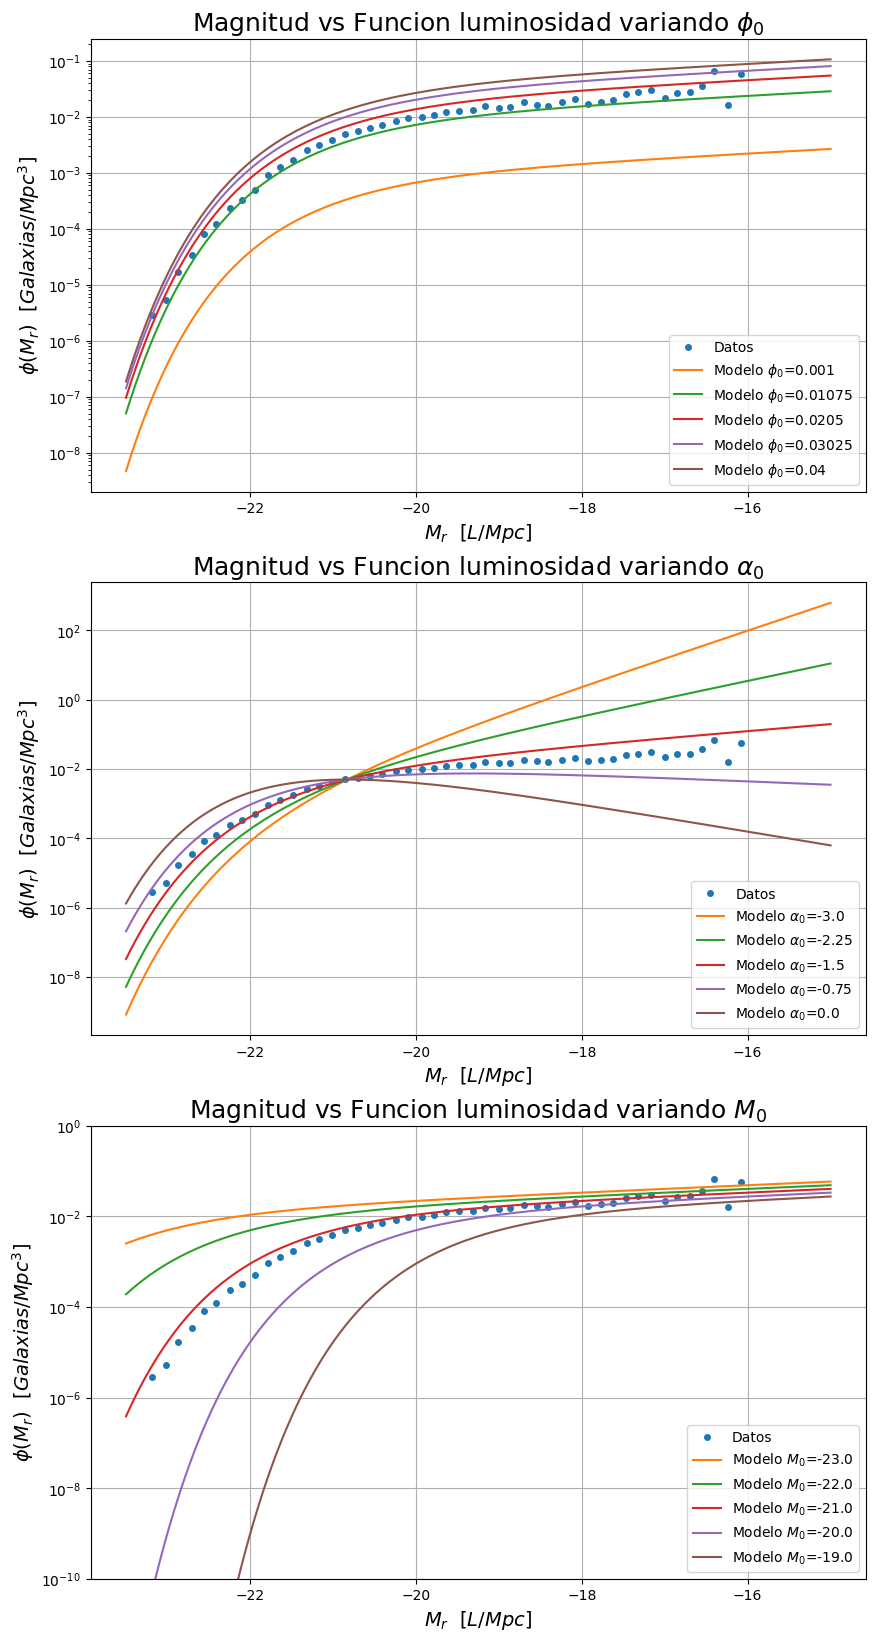

In [11]:
plt.figure(figsize=(10,20))
sx = np.linspace(-23.5, -15, 150)
sy = schechter(sx,0.0146,-1.20,-20.83) # estos valores son los obtenidos de Blanton et al. (2001).

plt.subplot(3,1,1)
plt.plot(df['MAG'],df['PHI'],'o',label = 'Datos',ms = 4)
for i in range(5):
    plt.plot(sx,p[i], label=f"Modelo $ \phi_0$={fi0[i]}")
plt.xlabel('$ M_r $  $[L/Mpc]$',fontsize = 14); plt.ylabel('$\phi(M_r)$  $[Galaxias/Mpc^3]$',fontsize = 14)
plt.yscale('log')
plt.grid()
plt.title('Magnitud vs Funcion luminosidad variando $\phi_0$',fontsize = 18 )
plt.legend(loc = 'best')

plt.subplot(3,1,2)
plt.plot(df['MAG'],df['PHI'],'o',label = 'Datos',ms = 4)
for i in range(5):
    plt.plot(sx,o[i], label=f"Modelo $\\alpha_0$={A0[i]}")
plt.xlabel('$ M_r $  $[L/Mpc]$',fontsize = 14); plt.ylabel('$\phi(M_r)$  $[Galaxias/Mpc^3]$',fontsize = 14)
plt.yscale('log')
plt.grid()
plt.title('Magnitud vs Funcion luminosidad variando $\\alpha_0$',fontsize = 18 )
plt.legend(loc = 'lower right')

plt.subplot(3,1,3)
plt.plot(df['MAG'],df['PHI'],'o',label = 'Datos',ms = 4)
for i in range(5):
    plt.plot(sx,q[i], label=f"Modelo $ M_0$={m0[i]}")
plt.xlabel('$ M_r $  $[L/Mpc]$',fontsize = 14); plt.ylabel('$\phi(M_r)$  $[Galaxias/Mpc^3]$',fontsize = 14)
plt.yscale('log')
plt.ylim(0.0000000001,1)
plt.grid()
plt.title('Magnitud vs Funcion luminosidad variando $M_0$',fontsize = 18 )
plt.legend(loc = 'best')

plt.show()

De estos graficos obtenemos los limites de los parametros, es decir, nuestro espacio de parametros. Se decidieron tomar los siguientes valores:

In [12]:
philim = [0.005,0.035]
Alim = [-1.66,-0.66]
Mlim = [-21.22,-20.33]

Ya que estos valores para los parametros encierran a todos los puntos de datos.

Si todo esta correctamente, la funcions postiriori deberia presentar un minimo(por construccion de la funcion likelihood) en los valores obtenidos por Baltom. Veamos si eso sucede.

<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:15: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_59333/1785281881.py:15: SyntaxWarning: invalid escape sequence '\p'
  plt.xlabel('$\phi_0$', fontsize=15)
/tmp/ipykernel_59333/1785281881.py:17: SyntaxWarning: invalid escape sequence '\p'
  plt.title('Exploración del Log Posterior vs. $\phi_0$', fontsize=16)


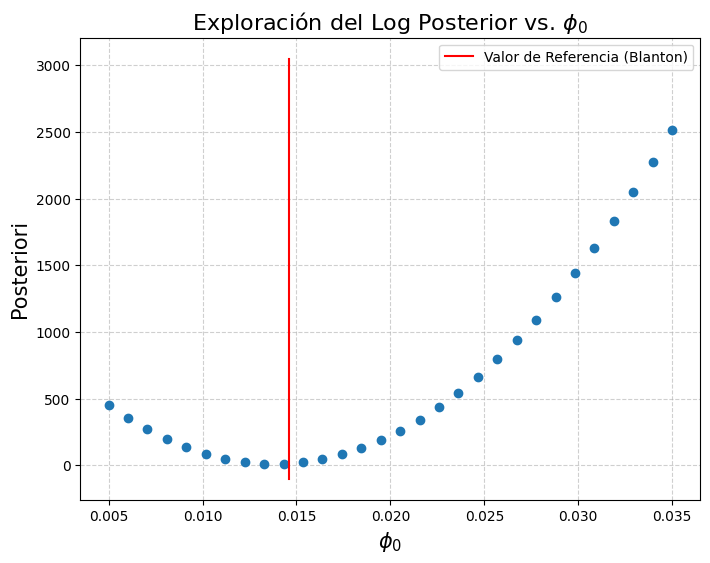

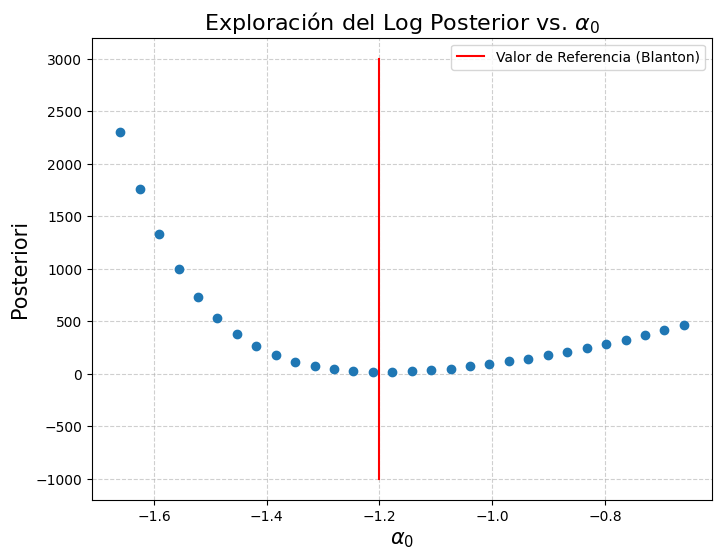

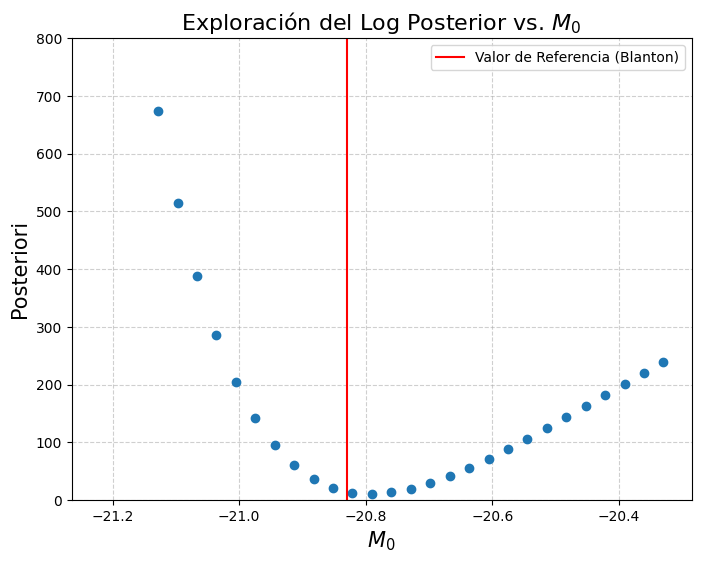

In [13]:
fi0c = np.linspace(0.005,0.035,30)
A0c = np.linspace(-1.66,-0.66,30)
m0c = np.linspace(-21.22,-20.33,30)
a = []
b = []
c = []
# --- Gráfico 1: Exploración de phi_0 ---
plt.figure(figsize=(8, 6)) # Nueva figura con tamaño estándar
for i in range(30):
    a.append(posteriori(df['MAG'], df['PHI'], fi0c[i], -1.2, -20.83, sigma, philim, Alim, Mlim))

plt.plot(fi0c, a, 'o')
plt.plot([0.0146, 0.0146], [-100, 3050], color="red", label='Valor de Referencia (Blanton)')
#plt.ylim(0,300)
plt.xlabel('$\phi_0$', fontsize=15)
plt.ylabel('Posteriori', fontsize=15)
plt.title('Exploración del Log Posterior vs. $\phi_0$', fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show() # Muestra el primer gráfico

# --- Gráfico 2: Exploración de alpha_0 ---
plt.figure(figsize=(8, 6)) # Nueva figura
for i in range(30):
    b.append(posteriori(df['MAG'], df['PHI'], 0.0146, A0c[i], -20.83, sigma, philim, Alim, Mlim))

plt.plot(A0c, b, 'o')
plt.plot([-1.20, -1.20], [-1000, 3000], color="red", label='Valor de Referencia (Blanton)')
#plt.ylim(0,500)
plt.xlabel('$\\alpha_0$', fontsize=15) # Corregí $A_0$ por $\alpha_0$ para el símbolo correcto
plt.ylabel('Posteriori', fontsize=15)
plt.title('Exploración del Log Posterior vs. $\\alpha_0$', fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show() # Muestra el segundo gráfico

# --- Gráfico 3: Exploración de M_0 ---
plt.figure(figsize=(8, 6)) # Nueva figura
for i in range(30):
    c.append(posteriori(df['MAG'], df['PHI'], 0.0146, -1.2, m0c[i], sigma, philim, Alim, Mlim))

plt.plot(m0c, c, 'o')
plt.plot([-20.83, -20.83], [-1000, 2000], color="red", label='Valor de Referencia (Blanton)')
plt.ylim(0, 800) # Mantengo tu límite de Y
plt.xlabel('$M_0$', fontsize=15)
plt.ylabel('Posteriori', fontsize=15)
plt.title('Exploración del Log Posterior vs. $M_0$', fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show() # Muestra el tercer gráfico

Una ves que tenemos las funciones definidas y probadas, junto con en espacio de parametros a estudiar, vamos a definir una función del algoritmo de Metrópolis-Hastings para luego recorrer el espacio de parametros y encontrar los mejores valores.

In [14]:
def metropolis(m,f,phi0,a0,m0,N,philim,Alim,Mlim,sigma): #aca los phi0,a0 y m0 son valores iniciales 
 #de donde va a comensar el algoritmo
    param = np.zeros((N,3))
    if priors(phi0,a0,m0,philim,Alim,Mlim) == 1:
        param[0][0],param[0][1],param[0][2] = phi0,a0,m0
    else:
        return ('Los parametros no estan dentro de los valores permitidos')
        return(None)
    poste = []
    rl = []
    for i in range(N-1):
        h = posteriori (m,f, param[i][0],param[i][1],param[i][2],sigma,philim,Alim,Mlim)
        poste.append(h)
        param[i+1][0] = param[i][0] + ((np.random.rand()*2.0)-1.0)*((philim[1]-philim[0])/80)
        param[i+1][1] = param[i][1] + ((np.random.rand()*2.0)-1.0)*((Alim[1]-Alim[0])/80)
        param[i+1][2] = param[i][2] + ((np.random.rand()*2.0)-1.0)*((Mlim[1]-Mlim[0])/80)      
        #
        if priors(param[i+1][0],param[i+1][1],param[i+1][2],philim,Alim,Mlim) == 1:
            k = posteriori (m,f, param[i+1][0],param[i+1][1],param[i+1][2],sigma,philim,Alim,Mlim)
            r = h-k
            rl.append(r)  
        #r = np.exp(r)           
            if r >= 0:
                continue #acepto derecho
            else:
                r = np.exp(r)
                random = np.random.random()
                #print(r,random)
                if random < r:
                    #print('Acepta')
                    continue
                else:
                    #print('No Acepta')
                    param[i+1][0] = param[i][0] 
                    param[i+1][1] = param[i][1]
                    param[i+1][2] = param[i][2]
        else:
            param[i+1][0] = param[i][0] 
            param[i+1][1] = param[i][1]
            param[i+1][2] = param[i][2]
    return(poste,rl,param)

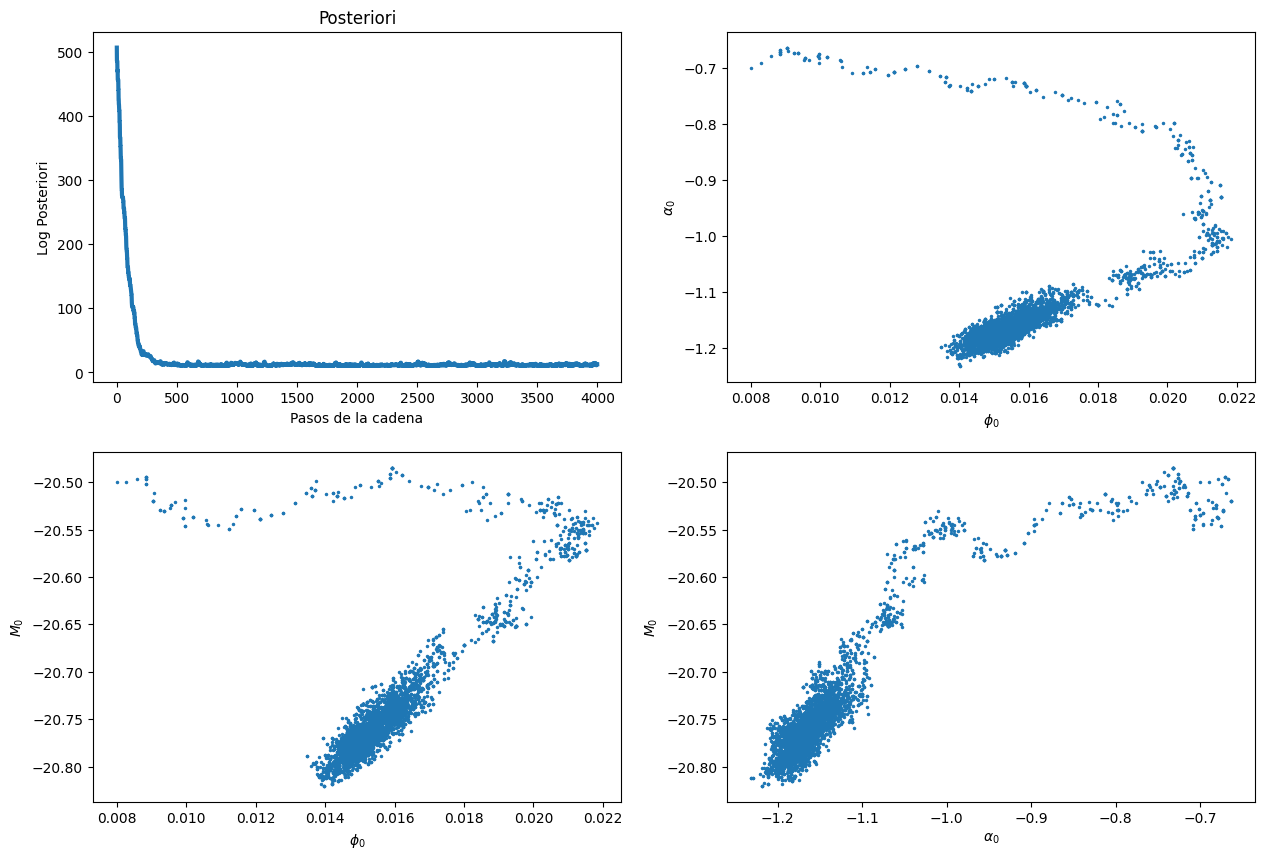

In [15]:
pos = metropolis(df['MAG'],df['PHI'],0.008,-0.7,-20.5,4000,philim,Alim,Mlim,sigma)[0]
par = metropolis(df['MAG'],df['PHI'],0.008,-0.7,-20.5,4000,philim,Alim,Mlim,sigma)[2]

plt.figure(figsize = (15,10))
plt.subplot(2,2,1)
plt.plot(pos,'-',lw = 3)
plt.title('Posteriori')
plt.xlabel('Pasos de la cadena')  
plt.ylabel('Log Posteriori')



# Subplot 2,2,2
plt.subplot(2,2,2)
plt.plot(par[:,0],par[:,1],'.',ms = 3)
plt.xlabel(r'$\phi_0$')           # Etiqueta para el eje x
plt.ylabel(r'$\alpha_0$')         # Etiqueta para el eje y

# Subplot 2,2,3
plt.subplot(2,2,3)
plt.plot(par[:,0],par[:,2],'.',ms = 3)
plt.xlabel(r'$\phi_0$')           # CORREGIDO (antes 'P$\phi_0$')
plt.ylabel(r'$M_0$')

# Subplot 2,2,4
plt.subplot(2,2,4)
plt.plot(par[:,1],par[:,2],'.',ms = 3)
plt.xlabel(r'$\alpha_0$')         # Etiqueta para el eje x
plt.ylabel(r'$M_0$')

plt.show()

Podemos hacer el promedio y la desviacion estandar de los parametros obtenidos desde el paso 500 en adelante(ya que para esos valores de pasos el likelihooh ya es "estable".)

In [16]:
phi0_mean = np.mean(par[700:,0])
phi0_desv = np.std(par[700:,0])
a0_mean = np.mean(par[700:,1])
a0_desv = np.std(par[700:,1])
M0_mean = np.mean(par[700:,2])
M0_desv = np.std(par[700:,2])
print('phi0_mean=',phi0_mean,'phi0_desv',phi0_desv)
print('a0_mean =',a0_mean,'a0_desv',a0_desv)
print('M0_mean =',M0_mean,'M0_desv ',M0_desv)

phi0_mean= 0.015307214043045511 phi0_desv 0.0006504189810803492
a0_mean = -1.1658212561368286 a0_desv 0.022656176112263917
M0_mean = -20.76280645078913 M0_desv  0.02304029242577684


# Ejercicio 4 y 5

Vamos a ver que obtenemos cuando realizamos un mal o un buen mezclado de las cadenas. Primero, vamos a tomar puntos de partida en nuestro espacio de parametros elegidos de forma aleatoria y en segundo lugar vamos a dividir a nuestro espacio en cuadrantres y haremos partir a las cadenas del centro de los mismos.

Si ahora realizamos varias caminatas en simultaneo, partiendo desde puntos aleatorios tendiamos que ver que todas las cadenas convergen a un mismo punto (region, dado que no van directamente hacia en minimo si no que pueden recorrer el espacio de parametros por construcción).

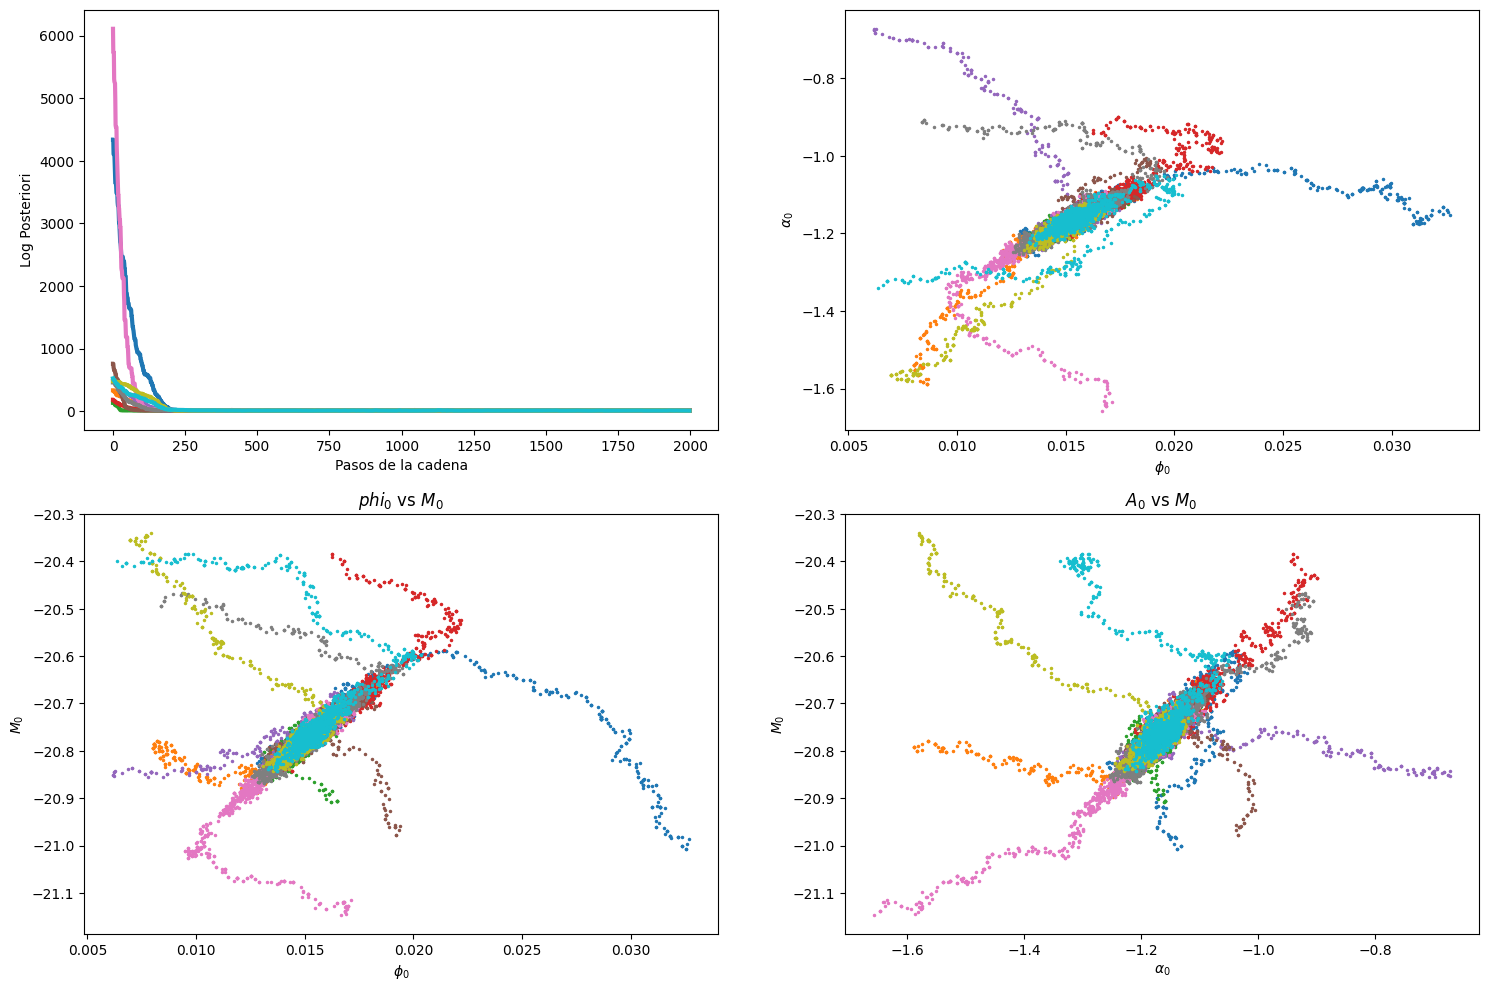

phi0_mean= 0.015297000640149664 phi0_desv 0.0009582737109091528
a0_mean = -1.1669605505555254 a0_desv 0.029797310300973823
M0_mean = -20.76433766773747 M0_desv  0.0366002024411158


In [18]:
philim = [0.005,0.035]
Alim = [-1.66,-0.66]
Mlim = [-21.22,-20.33]
phi0_mean = []
a0_mean = []
M0_mean = []
parametros = []

plt.figure(figsize = (18,12))
for i in range(10):
    fi0 = np.random.random()*0.030+0.005
    a0 = np.random.random()*1-1.66
    m0 = np.random.random()*0.89-21.22
    resultado_mcmc = metropolis(df['MAG'],df['PHI'],fi0,a0,m0,2000,philim,Alim,Mlim,sigma)
    pos = resultado_mcmc[0]
    par = resultado_mcmc[2]
    parametros.append(par)
    
    plt.subplot(2,2,1)
    plt.plot(pos,'-',lw = 3)
    #plt.ylim(0,1000,200)
    plt.xlabel('Pasos de la cadena')  
    plt.ylabel('Log Posteriori')


    plt.subplot(2,2,2)
    plt.plot(par[:,0],par[:,1],'.',ms = 3)
    plt.xlabel(r'$\phi_0$')           # Etiqueta para el eje x
    plt.ylabel(r'$\alpha_0$')         # Etiqueta para el eje y
    
    plt.subplot(2,2,3)
    plt.plot(par[:,0],par[:,2],'.',ms = 3)
    plt.title('$phi_0$ vs $M_0$ ')
    plt.xlabel(r'$\phi_0$')           # CORREGIDO (antes 'P$\phi_0$')
    plt.ylabel(r'$M_0$')
       
    plt.subplot(2,2,4)
    plt.plot(par[:,1],par[:,2],'.',ms = 3)
    plt.title('$A_0$ vs $M_0$ ')
    plt.xlabel(r'$\alpha_0$')         # Etiqueta para el eje x
    plt.ylabel(r'$M_0$')
            
    phi0_mean.append(par[500:,0])
    a0_mean.append(par[500:,1])
    M0_mean.append(par[500:,2])
    
plt.show()

print('phi0_mean=',np.mean(phi0_mean),'phi0_desv',np.std(phi0_mean))
print('a0_mean =',np.mean(a0_mean),'a0_desv',np.std(a0_mean))
print('M0_mean =',np.mean(M0_mean),'M0_desv ',np.std(M0_mean))

Si ahora dividimos los intervalos de cada uno de los parametros en 2 partes y tomando el valor central de cada unos de esos sub-intervalos vamos a tener 8 cadenas que comenzaran de puntos seleccionados.

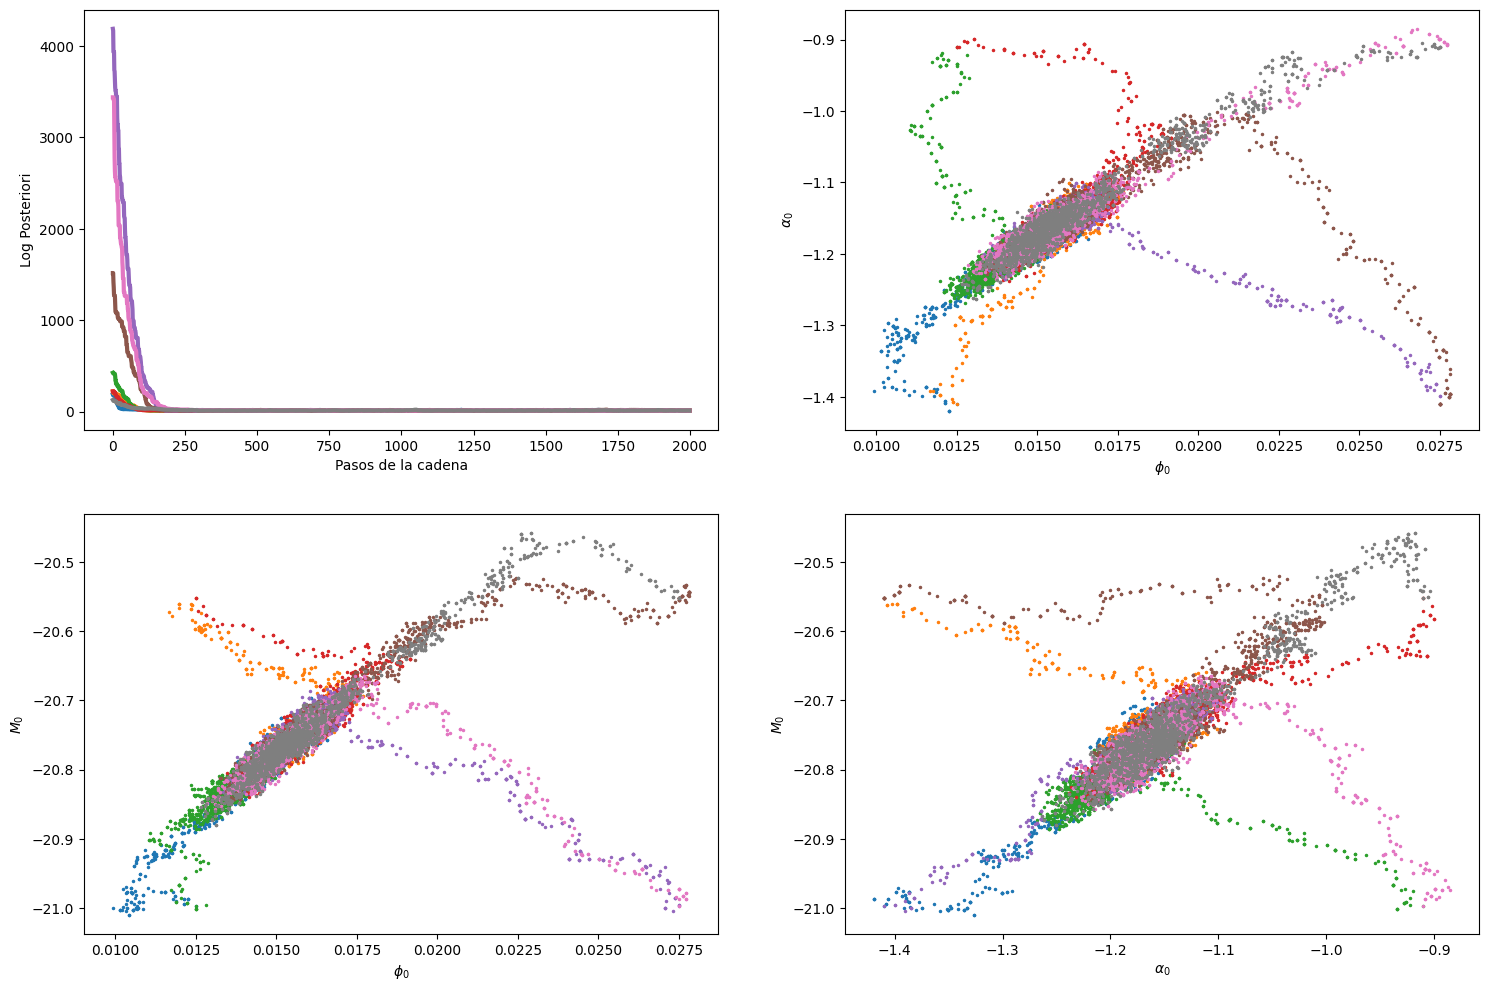

phi0_mean= 0.015297000640149664 phi0_desv 0.0009582737109091528
a0_mean = -1.1669605505555254 a0_desv 0.029797310300973823
M0_mean = -20.76433766773747 M0_desv  0.0366002024411158


In [19]:
philim = [0.005,0.035]
Alim = [-1.66,-0.66]
Mlim = [-21.22,-20.33]
plt.figure(figsize = (18,12))

fi0 = [0.0125, 0.0275] 
a0 = [-1.41,-0.91]
m0 = [-20.9975,-20.5525]

pos1 = []
par1 = []

phi0_mean1 = []
a0_mean1 = []
M0_mean1 = []

for i in range(2):
    for j in range(2):
        for k in range(2):
            val = metropolis(df['MAG'],df['PHI'],fi0[i],a0[j],m0[k],2000,philim,Alim,Mlim,sigma)[0]
            para = metropolis(df['MAG'],df['PHI'],fi0[i],a0[j],m0[k],2000,philim,Alim,Mlim,sigma)[2]
            pos1.append(val)
            par1.append(para)
            
for i in range(8):                        
    plt.subplot(2,2,1)
    plt.plot(pos1[i],'-',lw = 3)
    #plt.ylim(0,1000,200)
    plt.xlabel('Pasos de la cadena')
    plt.ylabel('Log Posteriori')

    plt.subplot(2,2,2)
    plt.plot(par1[i][:,0],par1[i][:,1],'.',ms = 3)
    plt.xlabel(r'$\phi_0$')           # Etiqueta para el eje x
    plt.ylabel(r'$\alpha_0$')         # Etiqueta para el eje y
    plt.subplot(2,2,3)
    plt.plot(par1[i][:,0],par1[i][:,2],'.',ms = 3)
    plt.xlabel(r'$\phi_0$')           # CORREGIDO (antes 'P$\phi_0$')
    plt.ylabel(r'$M_0$')

    plt.subplot(2,2,4)
    plt.plot(par1[i][:,1],par1[i][:,2],'.',ms = 3)
    plt.xlabel(r'$\alpha_0$')         # Etiqueta para el eje x
    plt.ylabel(r'$M_0$')
    
    phi0_mean1.append(np.mean(par1[i][500:,0]))
    a0_mean1.append(np.mean(par1[i][500:,1]))
    M0_mean1.append(np.mean(par1[i][500:,2]))
    
plt.show()

print('phi0_mean=',np.mean(phi0_mean),'phi0_desv',np.std(phi0_mean))
print('a0_mean =',np.mean(a0_mean),'a0_desv',np.std(a0_mean))
print('M0_mean =',np.mean(M0_mean),'M0_desv ',np.std(M0_mean))

Ahora, para visualizar la diferencia entre ambos mezclados vamos a graficar como van variando los valores de los parametros en funcion de los pasos para cada una de las cadenas. Tenemos que ver que el buen mezclado comienza sus cadenas con valores diferentes entre si y bien distribuidos en el espacio de parametros mientras que el mal mezclado no.

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_59333/3689282910.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\phi_0$')


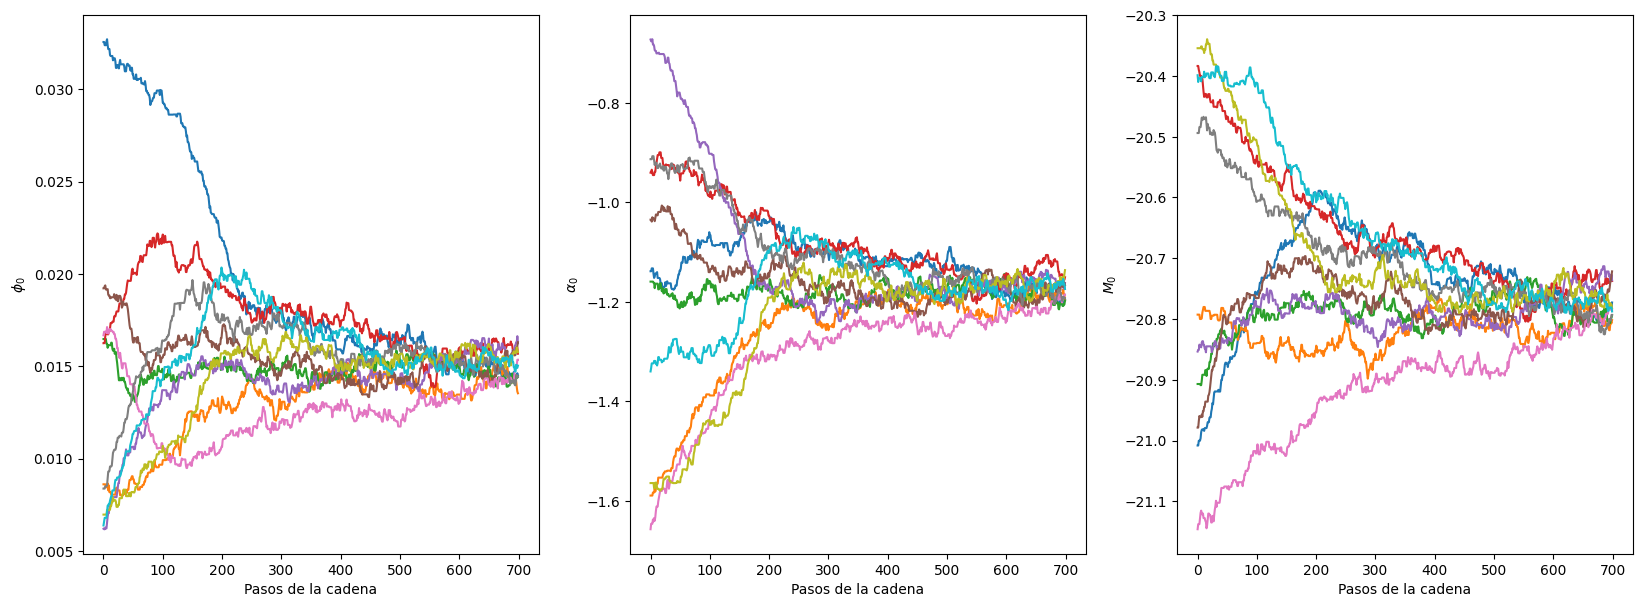

In [20]:
plt.figure(figsize = (20,7))
for i in range(10):
    plt.subplot(1,3,1)
    plt.plot(parametros[i][:700,0],'-',ms = 1)
    plt.xlabel('Pasos de la cadena')  
    plt.ylabel('$\phi_0$')
    plt.subplot(1,3,2)
    plt.plot(parametros[i][:700,1],'-',ms = 1)
    plt.xlabel('Pasos de la cadena')  
    plt.ylabel('$\\alpha_0$')
    plt.subplot(1,3,3)
    plt.plot(parametros[i][:700,2],'-',ms = 1)
    plt.xlabel('Pasos de la cadena')  
    plt.ylabel('$M_0$')
    
plt.show()

<>:6: SyntaxWarning: invalid escape sequence '\p'
<>:6: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_59333/4240870617.py:6: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\phi_0$')


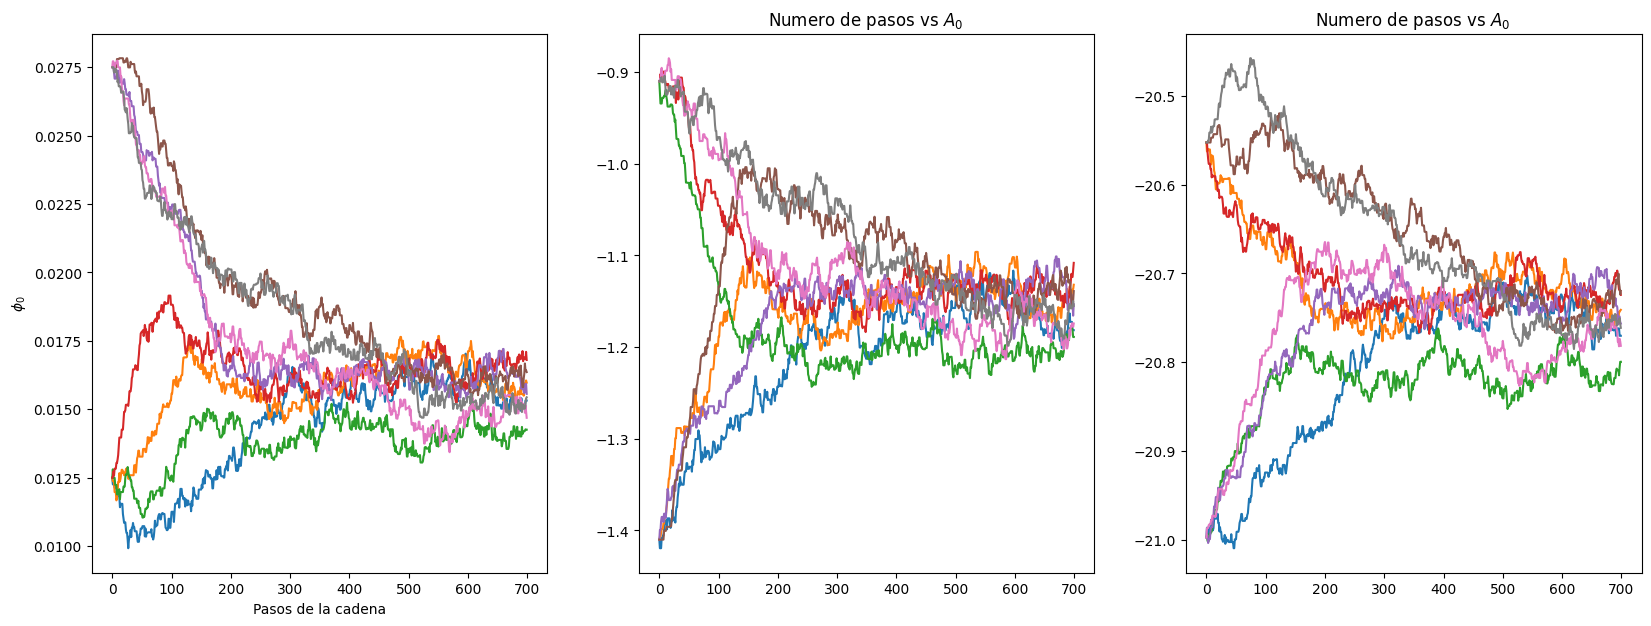

In [21]:
plt.figure(figsize = (20,7))
for i in range(8):
    plt.subplot(1,3,1)
    plt.plot(par1[i][:700,0],'-',ms = 1)
    plt.xlabel('Pasos de la cadena')  
    plt.ylabel('$\phi_0$')
    plt.subplot(1,3,2)
    plt.plot(par1[i][:700,1],'-',ms = 1)
    plt.title('Numero de pasos vs $A_0$ ')
    plt.subplot(1,3,3)
    plt.plot(par1[i][:700,2],'-',ms = 1)
    plt.title('Numero de pasos vs $A_0$ ')
    
plt.show()

# Ejercicio 6


El metodo del Gradiante descendiente nos permite encontrar los valores de los parametros que minimicen los valores de la función posteriori de manera mas directa que el algoritmo de Metrópolis-Hastings, ya que este no recorre el espacio de parametros tal cual lo hacia el anterior.

Defino primero la funcion dir_grad que va a ser la derivada en los parametros de la función posteriori dividido el modulo del gradiante, la cual me va a dar la dirección en la cual me tengo que mover para encontrer el minimo de la función.

In [22]:
M = df['MAG']
phi = df['PHI']

In [23]:
def dir_grad(M,phi,phi0,a0,M0,sigma):
    model = schechter(M,phi0,a0,M0)
    factor = - (phi - model)/(sigma**2)
    g = -0.4*(M - M0)
    
    der_phi = -np.sum(factor*model/phi0)
    der_a = -np.sum(factor*np.log(10)*g*model)
    der_m = -np.sum(factor*model*np.log(10)*0.4*(a0 + 1 - (10**g)))
    norma = np.sqrt(der_phi**2 + der_a**2 + der_m**2)
    
    ver_grad = np.zeros(3)
    ver_grad[0], ver_grad[1], ver_grad[2] = (der_phi/norma), (der_a/norma),(der_m/norma)
   
    grad = np.zeros(3)
    grad[0], grad[1], grad[2] = der_phi, der_a, der_m
    
    return(ver_grad,norma,grad,der_m)

Ahora, defino la función del gradiante descendiente, la cual es la que va a realizar la caminata por mi espacio de parametros.

In [24]:
def grad_des(M,phi,phi0,a0,m0,N,sigma):
    par = np.zeros((N,3))
    par[0][0],par[0][1],par[0][2] = phi0, a0, m0
   
    for i in range(N-1):
        ver_grad = dir_grad(M,phi,par[i][0],par[i][1],par[i][2],sigma)[0]
      
        par[i+1][0] = par[i][0] + ver_grad[0]*(2*10**-5) #phi (2*10**-5)
        par[i+1][1] = par[i][1] + ver_grad[1]*(2*10**-1) #alpha (2*10**-1)
        par[i+1][2] = par[i][2] + ver_grad[2]*(2*10**-3) #m0 (2*10**-3)
        
    return(par)

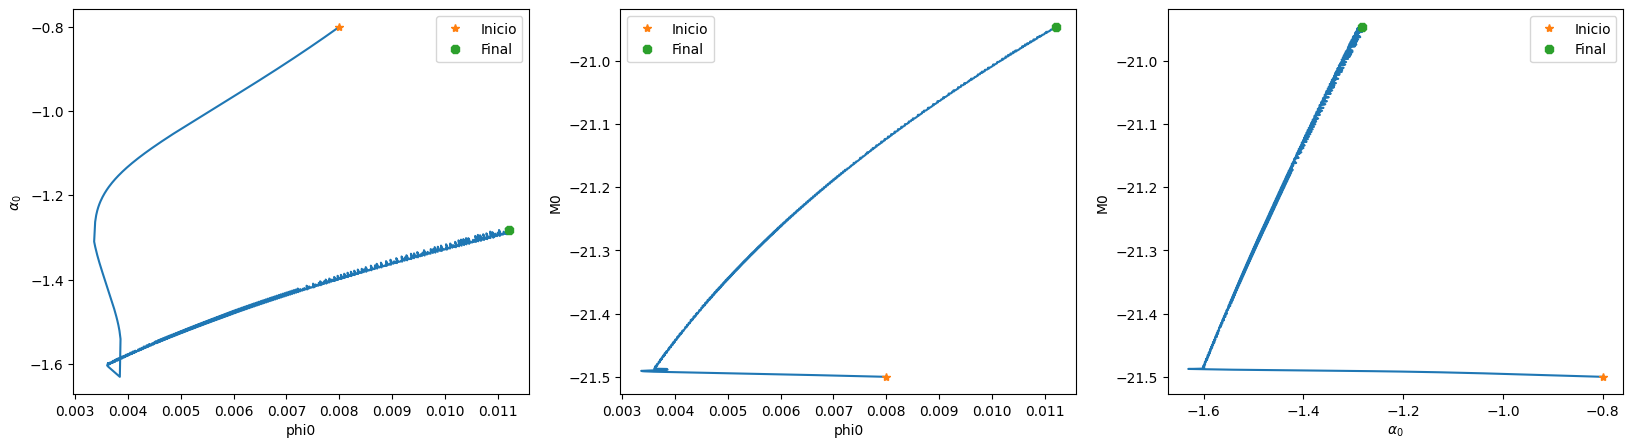

phi final = 0.011202689710369078
alpha final = -1.283331981606079
M0 final = -20.946470855237347


In [25]:
y0 = grad_des(M,phi,0.008,-0.8,-21.5,1000,sigma)

plt.figure(figsize = (20,5))

plt.subplot(1,3,1)
plt.plot(y0[:,0],y0[:,1],'-',ms = 2)
plt.plot(y0[0,0],y0[0,1],'*',ms = 6,label = 'Inicio')
plt.plot(y0[-1,0],y0[-1,1],'8',ms = 6,label = 'Final')
plt.xlabel('phi0')
plt.ylabel('$\\alpha_0$')
plt.legend(loc = 0)

plt.subplot(1,3,2)
plt.plot(y0[:,0],y0[:,2],'-',ms = 2)
plt.plot(y0[0,0],y0[0,2],'*',ms = 6,label = 'Inicio')
plt.plot(y0[-1,0],y0[-1,2],'8',ms = 6,label = 'Final')
plt.xlabel('phi0')
plt.ylabel('M0')
plt.legend(loc = 0)

plt.subplot(1,3,3)
plt.plot(y0[:,1],y0[:,2],'-',ms = 2)
plt.plot(y0[0,1],y0[0,2],'*',ms = 6,label = 'Inicio')
plt.plot(y0[-1,1],y0[-1,2],'8',ms = 6,label = 'Final')
plt.xlabel('$\\alpha_0$')
plt.ylabel('M0')
plt.legend(loc = 0)

plt.show()

print('phi final =',y0[-1,0])
print('alpha final =',y0[-1,1])
print('M0 final =',y0[-1,2])

Estos valores obtenidos no difieren en gran medida con los valores encontrados por Balton.

Si ahora realizamos varias cadenas tenemos que observar que con los suficientes pasos estas convergen a un mismo punto en el espacio de parametros.

<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
<>:16: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_59333/4004674799.py:16: SyntaxWarning: invalid escape sequence '\p'
  plt.title('$ \phi_0 $ vs $ A_0 $')
/tmp/ipykernel_59333/4004674799.py:23: SyntaxWarning: invalid escape sequence '\p'
  plt.title('$ \phi_0 $ vs $ M_0 $')


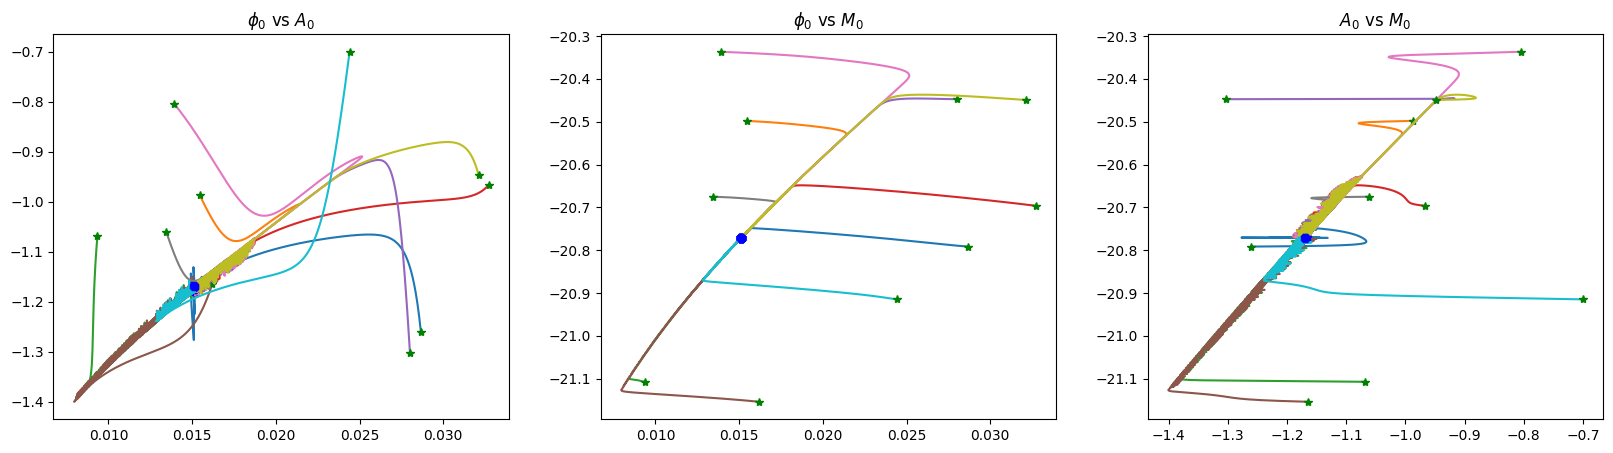

phi0_mean= 0.015115262606924413 phi0_desv= 8.992065544477089e-06
a0_mean= -1.170844789761233 a0_desv= 0.003919078924312622
m0_mean= -20.77096617893906 m0_desv= 3.235461139099994e-05


In [26]:
plt.figure(figsize = (20,5))
phi_final = []
a_final = []
m_final = []
for i in range(10):
    fi0 = np.random.random()*0.030+0.005
    a0 = np.random.random()*1-1.66
    m0 = np.random.random()*0.89-21.22
    y0 = grad_des(M,phi,fi0,a0,m0,3000,sigma)
    phi_final.append(y0[-1,0]), a_final.append(y0[-1,1]) , m_final.append(y0[-1,2])
    
    plt.subplot(1,3,1)
    plt.plot(y0[:,0],y0[:,1],'-',ms = 2)
    plt.plot(y0[0,0],y0[0,1],'*',color = 'green',ms = 6,label = 'Inicio')
    plt.plot(y0[-1,0],y0[-1,1],'8',color = 'b',ms = 6,label = 'Final')
    plt.title('$ \phi_0 $ vs $ A_0 $')
    
    
    plt.subplot(1,3,2)
    plt.plot(y0[:,0],y0[:,2],'-',ms = 2)
    plt.plot(y0[0,0],y0[0,2],'*',color = 'green',ms = 6,label = 'Inicio')
    plt.plot(y0[-1,0],y0[-1,2],'8',color = 'b',ms = 6,label = 'Final')
    plt.title('$ \phi_0 $ vs $ M_0 $')
    
    
    plt.subplot(1,3,3)
    plt.plot(y0[:,1],y0[:,2],'-',ms = 2)
    plt.plot(y0[0,1],y0[0,2],'*',color = 'green',ms = 6,label = 'Inicio')
    plt.plot(y0[-1,1],y0[-1,2],'8',color = 'b',ms = 6,label = 'Final')
    plt.title('$ A_0 $ vs $ M_0 $')
    
plt.show()

print('phi0_mean=',np.mean(phi_final),'phi0_desv=',np.std(phi_final))
print('a0_mean=',np.mean(a_final),'a0_desv=',np.std(a_final))
print('m0_mean=',np.mean(m_final),'m0_desv=',np.std(m_final))